# DOWNLOADING LIBRARIES

In [1]:
#pip install opensmile

In [2]:
# pip install praat-parselmouth

In [3]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [4]:
#pip install timm==0.4.5

In [5]:
# pip install xgboost

In [6]:
# pip install wget

In [7]:
# pip install torchinfo

In [8]:
# pip install librosa==0.9.2

In [9]:
# pip install efficientnet_pytorch

# IMPORTING LIBRARIES

In [1]:
# checking librosa version
import librosa
print(librosa.__version__)

0.11.0


In [2]:
# Defining directory as modules are stored in a specific folder
import os

os.chdir("/home/marcos/Documentos/GitHub/TFM_code/src")
print(os.getcwd())  # Print the current working directory to confirm


/home/marcos/Documentos/GitHub/TFM_code/src


In [3]:
from torch.hub import load_state_dict_from_url
import os

# Specify a directory that is writable
os.environ['TORCH_HOME'] = "/home/marcos/Documentos/GitHub/TFM_code/src/models"

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import wget
import shutil

# Machine learning and PyTorch
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary

# Importar project modules
from traintest_without_GRL import train_without_GRL, validate_without_GRL
import models
from models import *
from utilities import *
import dataloader
from data import humv_loader

import warnings
warnings.filterwarnings("ignore")

# Load data

In [5]:
# 1. Load data
from data import humv_loader
df = humv_loader.load_audio_data('/home/marcos/Documentos/GitHub/TFM_code/data/raw')
df_binary = humv_loader.filter_binary(df, [0, 2])  # HC vs PD

Loaded 472 audio files.
Label distribution:
Label
0    239
1    119
2    114
Name: count, dtype: int64
Filtered DataFrame shape: (353, 4)
Label distribution after filtering:
Label
0    239
1    114
Name: count, dtype: int64


In [6]:
df.head()

,Patient,Label,File_Path,Audio_Name
0,HUMV_HC_10,0,/home/marcos/Documentos/GitHub/TFM_code/data/r...,ka
1,HUMV_HC_10,0,/home/marcos/Documentos/GitHub/TFM_code/data/r...,vocal
2,HUMV_HC_10,0,/home/marcos/Documentos/GitHub/TFM_code/data/r...,ta
3,HUMV_HC_10,0,/home/marcos/Documentos/GitHub/TFM_code/data/r...,patachaka
4,HUMV_HC_10,0,/home/marcos/Documentos/GitHub/TFM_code/data/r...,lectura texto


# Preprocess audio data

In [7]:
# 2. Preprocess
from preprocessing import audio_processor
audio_chunks, labels, patient_ids, exercises = audio_processor.execute_preprocess_and_split(df_binary, start_time=0, chunk_duration=5, max_duration=15, target_sr=16000, remove_silence=True, top_db=25)

Total chunks generated: 682
Unique exercises: ['aueoi' 'fluencia categorial' 'habla libre' 'ka' 'lectura texto' 'pa'
 'patachaka' 'pataka' 'robo galletas' 'ta' 'uy' 'vocal']


# Extract features

## Opensmile

In [ ]:
# 3. Extract features
from features import opensmile
features_df_opensmile = opensmile.extract_opensmile_features(audio_chunks, labels, patient_ids, exercises)


100%|██████████| 682/682 [00:29<00:00, 22.92it/s]


OpenSMILE features shape: (682, 6376)
Unique exercises: ['ka' 'ta' 'patachaka' 'lectura texto' 'pa' 'robo galletas' 'aueoi'
 'pataka' 'fluencia categorial' 'uy' 'habla libre' 'vocal']


In [ ]:
features_df_opensmile.shape

In [ ]:
features_df_opensmile.head(5)

,patient_id,label,exercise,audspec_lengthL1norm_sma_range,audspec_lengthL1norm_sma_maxPos,audspec_lengthL1norm_sma_minPos,audspec_lengthL1norm_sma_quartile1,audspec_lengthL1norm_sma_quartile2,audspec_lengthL1norm_sma_quartile3,audspec_lengthL1norm_sma_iqr1-2,...,mfcc_sma_de[14]_peakRangeAbs,mfcc_sma_de[14]_peakRangeRel,mfcc_sma_de[14]_peakMeanAbs,mfcc_sma_de[14]_peakMeanMeanDist,mfcc_sma_de[14]_peakMeanRel,mfcc_sma_de[14]_minRangeRel,mfcc_sma_de[14]_meanRisingSlope,mfcc_sma_de[14]_stddevRisingSlope,mfcc_sma_de[14]_meanFallingSlope,mfcc_sma_de[14]_stddevFallingSlope
0,HUMV_HC_10,0,ka,2.559695,0.034483,0.000000,0.822993,1.415665,1.661336,0.592672,...,9.396669,0.643907,3.098620,3.111894,-19.925762,0.401179,116.660881,56.385323,120.637718,77.799385
1,HUMV_HC_10,0,ka,1.445670,0.681542,0.831643,0.755188,1.184325,1.326842,0.429136,...,8.379049,0.597406,2.451422,2.464013,-19.872738,0.415276,90.029572,46.227768,117.352409,82.202354
2,HUMV_HC_10,0,ta,3.336017,0.018256,0.000000,0.571553,1.219136,1.437897,0.647584,...,9.210089,0.687946,3.022422,3.015630,19.992964,0.442215,105.236549,59.063530,113.002464,63.753204
3,HUMV_HC_10,0,ta,1.241985,0.194726,0.776876,0.466628,0.995015,1.126855,0.528387,...,8.520338,0.557363,3.202053,3.221778,-19.791512,0.489874,105.353653,66.039597,118.989746,83.138031
4,HUMV_HC_10,0,patachaka,3.526533,0.565923,0.000000,0.612897,0.987001,1.670974,0.374104,...,9.710917,0.614867,3.263508,3.272584,-19.983335,0.403413,128.979248,69.271103,130.664520,57.430038


## Praat

In [ ]:
from features import praat
features_df_praat = praat.extract_praat_features(audio_chunks, labels, patient_ids, exercises)


100%|██████████| 682/682 [00:24<00:00, 27.65it/s]

Praat features shape: (682, 17)
Unique exercises: ['ka' 'ta' 'patachaka' 'lectura texto' 'pa' 'robo galletas' 'aueoi'
 'pataka' 'fluencia categorial' 'uy' 'habla libre' 'vocal']


In [ ]:
features_df_praat.shape

(682, 17)

In [ ]:
features_df_praat.head(5)

,patient_id,label,exercise,pitch_mean,pitch_min,pitch_max,pitch_std,f1_mean,f2_mean,f3_mean,intensity_mean,intensity_min,intensity_max,intensity_std,jitter,shimmer,hnr_mean
0,HUMV_HC_10,0,ka,113.904044,104.396721,131.810488,3.739172,610.366456,1542.190472,2584.707019,79.077514,52.542388,86.535344,7.669270,0.017818,0.062980,-15.053595
1,HUMV_HC_10,0,ka,112.719483,101.553731,127.345986,3.144213,469.657133,1366.344729,2593.676846,78.410305,54.667999,84.461567,7.154222,0.015691,0.060583,-1.075279
2,HUMV_HC_10,0,ta,112.452781,104.095601,135.396242,3.981292,526.921771,1613.732481,2665.020714,78.593399,56.325229,86.113474,7.909220,0.015419,0.061161,-23.473976
3,HUMV_HC_10,0,ta,112.238623,105.147017,126.421236,3.301270,538.798188,1664.873686,2847.759784,76.981751,53.407459,83.538434,7.990124,0.013970,0.059641,-9.825330
4,HUMV_HC_10,0,patachaka,118.286680,102.929636,140.731981,7.594256,665.672000,1577.755875,2735.141002,75.374459,51.691403,85.416336,7.496380,0.033798,0.113923,-38.762141


## Librosa

In [18]:
from features import librosa_features
features_df_librosa = librosa_features.extract_librosa_features(audio_chunks, labels, patient_ids, exercises)

100%|██████████| 682/682 [00:07<00:00, 93.30it/s]

Librosa features shape: (682, 47)
Unique exercises: ['ka' 'ta' 'patachaka' 'lectura texto' 'pa' 'robo galletas' 'aueoi'
 'pataka' 'fluencia categorial' 'uy' 'habla libre' 'vocal']


# Training

In [ ]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    }
    {
        "kernel": ["poly"],
        "C": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100],
        "degree": [2, 3, 4, 5]
    }
    {
        "kernel": ["sigmoid"],
        "C": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    }
]

In [ ]:
# 4. Train per exercise
from sklearn.svm import SVC
from training import SklearnTrainer

# Specify feature data frame to use for training
features_df = features_df_praat.copy()

for exercise in np.unique(exercises):
    mask = features_df['exercise'].str.contains(exercise, na=False) | (exercises == exercise)
    
    X = features_df.drop(columns=['patient_id', 'label', 'exercise']).values[mask]
    y = features_df['label'].values[mask]
    patient_ids_ex = patient_ids[mask]
    
    model = SVC(probability=False, class_weight = 'balanced')
    trainer = SklearnTrainer(model=model, param_grid=param_grid, n_splits=5, random_state=42)
    
    results = trainer.train(
        X, y, patient_ids_ex,
        exercise=exercise,  # Auto-used in file naming!
        feature_type='praat',
        save_dir='/home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/prueba_2_HC_PD_5s_clip_15s_audio_SVM_PRAAT'
    )


Training with 5-fold outer CV
Total unique patients: 28
Patients per class: {0: 19, 1: 9}
X shape: (59, 14), y shape: (59,)


=== Fold 1/5 ===
  Outer - Train patients: {0: 15, 1: 7}
  Outer - Test patients: {0: 4, 1: 2}
  Inner CV - Train: {0: 10, 1: 5}, Val: {0: 5, 1: 2}
  Inner CV - Train: {0: 10, 1: 4}, Val: {0: 5, 1: 3}
  Inner CV - Train: {0: 10, 1: 5}, Val: {0: 5, 1: 2}
  Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Segment-level - Acc: 0.643, AUC: 0.450
  Patient-level - Acc: 0.500, AUC: 0.375

=== Fold 2/5 ===
  Outer - Train patients: {0: 16, 1: 6}
  Outer - Test patients: {0: 3, 1: 3}
  Inner CV - Train: {0: 10, 1: 5}, Val: {0: 6, 1: 1}
  Inner CV - Train: {0: 11, 1: 3}, Val: {0: 5, 1: 3}
  Inner CV - Train: {0: 11, 1: 4}, Val: {0: 5, 1: 2}
  Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Segment-level - Acc: 0.727, AUC: 0.786
  Patient-level - Acc: 0.500, AUC: 0.889

=== Fold 3/5 ===
  Outer - Train patients: {0: 15, 1: 8}
  Outer - Test patient

ValueError: n_splits=5 cannot be greater than the number of members in each class.

In [8]:
X = features_df.drop(columns=['patient_id', 'label']).values
y = features_df['label'].values
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"patient_ids: {len(features_df['patient_id'].values)} unique = {len(np.unique(features_df['patient_id'].values))}")
print(f"Unique patient_ids: {np.unique(features_df['patient_id'].values)[:5]}...")  # First 5

X shape: (682, 6373)
y shape: (682,)
patient_ids: 682 unique = 30
Unique patient_ids: ['HUMV_HC_1' 'HUMV_HC_10' 'HUMV_HC_2' 'HUMV_HC_3' 'HUMV_HC_4']...


In [9]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    }
]

In [10]:
# 4. Train ML model (auto patient-level CV)
from models.sklearn import SVMClassifier
from sklearn.svm import SVC
from training import SklearnTrainer
X = features_df.drop(columns=['patient_id', 'label']).values
y = features_df['label'].values
model = SVC(probability=False, class_weight = 'balanced')
trainer = SklearnTrainer(model=model, param_grid=param_grid, n_splits=5, random_state=42)
results = trainer.train(X, y, features_df['patient_id'].values, save_dir='/home/marcos/Documentos/GitHub/TFM_code/outputs/experiments/prueba_2_HC_PD_5s_clip_15s_audio_SVM_OpenSmile')  # No leakage!


Training with 5-fold outer CV
Total unique patients: 30
Patients per class: {0: 20, 1: 10}
X shape: (682, 6373), y shape: (682,)


=== Fold 1/5 ===
  Outer - Train patients: {0: 16, 1: 8}
  Outer - Test patients: {0: 4, 1: 2}
  Inner CV - Train: {0: 10, 1: 6}, Val: {0: 6, 1: 2}
  Inner CV - Train: {0: 11, 1: 5}, Val: {0: 5, 1: 3}
  Inner CV - Train: {0: 11, 1: 5}, Val: {0: 5, 1: 3}


/home/marcos/software/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/marcos/software/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/marcos/software/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

  Best params: {'C': 1e-05, 'gamma': 'scale', 'kernel': 'rbf'}
  Segment-level - Acc: 0.298, AUC: 0.560
  Patient-level - Acc: 0.333, AUC: 0.750

=== Fold 2/5 ===
  Outer - Train patients: {0: 16, 1: 8}
  Outer - Test patients: {0: 4, 1: 2}
  Inner CV - Train: {0: 10, 1: 6}, Val: {0: 6, 1: 2}
  Inner CV - Train: {0: 11, 1: 5}, Val: {0: 5, 1: 3}
  Inner CV - Train: {0: 11, 1: 5}, Val: {0: 5, 1: 3}
  Best params: {'C': 0.001, 'gamma': 'auto', 'kernel': 'rbf'}
  Segment-level - Acc: 0.719, AUC: 0.665
  Patient-level - Acc: 0.667, AUC: 0.875

=== Fold 3/5 ===
  Outer - Train patients: {0: 16, 1: 8}
  Outer - Test patients: {0: 4, 1: 2}
  Inner CV - Train: {0: 10, 1: 6}, Val: {0: 6, 1: 2}
  Inner CV - Train: {0: 11, 1: 5}, Val: {0: 5, 1: 3}
  Inner CV - Train: {0: 11, 1: 5}, Val: {0: 5, 1: 3}
  Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Segment-level - Acc: 0.759, AUC: 0.838
  Patient-level - Acc: 0.667, AUC: 1.000

=== Fold 4/5 ===
  Outer - Train patients: {0: 16, 1: 8}
 

In [20]:
from preprocessing.splitter import split_by_patients
for train_idx, test_idx in split_by_patients(patient_ids, labels):
    # This assertion guarantees no patient appears in both train and test
    assert set(patient_ids[train_idx]).isdisjoint(set(patient_ids[test_idx]))

# LOADING DATA OF UNIQUE AUDIO EXERCISES

## Loading HC vs PD data

In [29]:
# Define directories for both datasets
#dir_1 = r'D:\processed_audio\balanced\HC_vs_PD_5s_with_1s_overlap_HUMV_all_audio'
dir_1 = r'D:\processed_audio\balanced\HC_vs_PD_5s_with_1s_overlap_HUMV_all_audio_raw_22050Hz'

# Load both datasets
all_patient_ids_HUMV, all_labels_HUMV, all_audio_segments_HUMV, _ = utils_audio_PD_project.load_processed_audio_dataset(dir_1, 0, GRL=False, exercise_names = ["uy", "ta", "pa", "ka", "pataka", "patachaka", "aueoi", "lectura texto", "habla libre", "robo galletas", "fluencia categorial"]) #

# all_patient_ids, all_labels, all_audio_segments, _ = utils_audio_PD_project.load_processed_audio_dataset(dir_1, 0, GRL=False, exercise_names = ["uy"])


# Check final dataset sizes
print(f"Total audio segments: {len(all_audio_segments_HUMV)}")
print(f"Total labels: {len(all_labels_HUMV)}")
print(f"Total patient IDs: {len(all_patient_ids_HUMV)}")

# Validate label distribution
print(f"Final label distribution: {np.bincount(all_labels_HUMV)}")


Loading dataset from: D:\processed_audio\balanced\HC_vs_PD_5s_with_1s_overlap_HUMV_all_audio_raw_22050Hz
Selected exercises: ['uy', 'ta', 'pa', 'ka', 'pataka', 'patachaka', 'aueoi', 'lectura texto', 'habla libre', 'robo galletas', 'fluencia categorial']
Sorted Patient ID files: ['patient_ids_5s_with_1s_overlap_aueoi.npy', 'patient_ids_5s_with_1s_overlap_fluencia categorial.npy', 'patient_ids_5s_with_1s_overlap_habla libre.npy', 'patient_ids_5s_with_1s_overlap_ka.npy', 'patient_ids_5s_with_1s_overlap_lectura texto.npy', 'patient_ids_5s_with_1s_overlap_pa.npy', 'patient_ids_5s_with_1s_overlap_patachaka.npy', 'patient_ids_5s_with_1s_overlap_pataka.npy', 'patient_ids_5s_with_1s_overlap_robo galletas.npy', 'patient_ids_5s_with_1s_overlap_ta.npy', 'patient_ids_5s_with_1s_overlap_uy.npy']
Sorted Label files: ['labels_5s_with_1s_overlap_aueoi.npy', 'labels_5s_with_1s_overlap_fluencia categorial.npy', 'labels_5s_with_1s_overlap_habla libre.npy', 'labels_5s_with_1s_overlap_ka.npy', 'labels_5s_wi

## Loading AC data

In [33]:
# Define directories for both datasets
dir_1 = r'D:\processed_audio\AC_5s_with_1s_overlap_HUMV_all_audio'
dir_1 = r'D:\processed_audio\AC_5s_with_1s_overlap_HUMV_all_audio_22050Hz_raw'

# Load both datasets
all_patient_ids_HUMV_AC, all_labels_HUMV_AC, all_audio_segments_HUMV_AC, _ = utils_audio_PD_project.load_processed_audio_dataset(dir_1, 0, GRL=False, exercise_names = ["uy", "ta", "pa", "ka", "pataka", "patachaka", "aueoi", "lectura texto", "habla libre", "robo galletas", "fluencia categorial"]) #

# Check final dataset sizes
print(f"Total audio segments: {len(all_audio_segments_HUMV_AC)}")
print(f"Total labels: {len(all_labels_HUMV_AC)}")
print(f"Total patient IDs: {len(all_patient_ids_HUMV_AC)}")

# Validate label distribution
print(f"Final label distribution: {np.bincount(all_labels_HUMV_AC)}")

Loading dataset from: D:\processed_audio\AC_5s_with_1s_overlap_HUMV_all_audio_22050Hz_raw
Selected exercises: ['uy', 'ta', 'pa', 'ka', 'pataka', 'patachaka', 'aueoi', 'lectura texto', 'habla libre', 'robo galletas', 'fluencia categorial']
Sorted Patient ID files: ['AC_patient_ids_5s_with_1s_overlap_aueoi.npy', 'AC_patient_ids_5s_with_1s_overlap_fluencia categorial.npy', 'AC_patient_ids_5s_with_1s_overlap_habla libre.npy', 'AC_patient_ids_5s_with_1s_overlap_ka.npy', 'AC_patient_ids_5s_with_1s_overlap_lectura texto.npy', 'AC_patient_ids_5s_with_1s_overlap_pa.npy', 'AC_patient_ids_5s_with_1s_overlap_patachaka.npy', 'AC_patient_ids_5s_with_1s_overlap_pataka.npy', 'AC_patient_ids_5s_with_1s_overlap_robo galletas.npy', 'AC_patient_ids_5s_with_1s_overlap_ta.npy', 'AC_patient_ids_5s_with_1s_overlap_uy.npy']
Sorted Label files: ['AC_labels_5s_with_1s_overlap_aueoi.npy', 'AC_labels_5s_with_1s_overlap_fluencia categorial.npy', 'AC_labels_5s_with_1s_overlap_habla libre.npy', 'AC_labels_5s_with_1s_

# LOADING THE MODEL

In [12]:
from models import Models
audio_model = Models.ResNetAttention(label_dim=2, pretrain=True, dropatt_rate = 0.2, dropout_rate=0.2)
print("ResNetAttention loaded successfully!")

Now Use ImageNet Pretrained ResNet50 Model.
ResNetAttention loaded successfully!


In [13]:
pretrained_path = r'D:\Audio_Classification_HUMV_without_GRL\pretrained_models\audioset_10_10_0.4593.pth'

if not os.path.exists(pretrained_path):
    # Download only if file doesn't exist
    audioset_mdl_url = 'https://www.dropbox.com/s/cv4knew8mvbrnvq/audioset_0.4593.pth?dl=1'
    # Save to the desired location with the correct filename
    wget.download(audioset_mdl_url, out=pretrained_path)
    print(f"Downloaded weights to {pretrained_path}")
else:
    print(f"Weights file already exists at {pretrained_path}, skipping download.")

Weights file already exists at D:\Audio_Classification_HUMV_without_GRL\pretrained_models\audioset_10_10_0.4593.pth, skipping download.


In [14]:
from models import *
audio_model = ASTModel(
    label_dim=2,
    fstride=10, tstride=10,
    input_fdim=128, input_tdim=501,
    imagenet_pretrain=True,
    audioset_pretrain=True,
    dropout_type="attention",
    mlp_dropout_p=0.2, 
    attention_dropout_p=0.2
    )
print("ASTModel loaded successfully!")

---------------AST Model Summary---------------
ImageNet pretraining: True, AudioSet pretraining: True
Label dimension=2
Frequency stride=10, time stride=10
number of patches=588
ASTModel loaded successfully!


In [15]:
# Calculate total parameters and trainable parameters
trainables = [p for p in audio_model.parameters() if p.requires_grad]
print('Total parameter number is: {:.3f} million'.format(
    sum(p.numel() for p in audio_model.parameters()) / 1e6))
print('Total trainable parameter number is: {:.3f} million'.format(
    sum(p.numel() for p in trainables) / 1e6))

Total parameter number is: 87.249 million
Total trainable parameter number is: 87.249 million


In [16]:
# Provide input size matching your model's expected input dimensions
# Example: (batch_size, channels, time_frames, frequency_bins)
input_size = (32, 501, 128)

# Display model summary
summary(audio_model, input_size=input_size, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
ASTModel                                           [32, 501, 128]            [32, 2]                   --                        True
├─DistilledVisionTransformer: 1-1                  --                        --                        1,992,656                 True
│    └─PatchEmbed: 2-1                             [32, 1, 128, 501]         [32, 588, 768]            --                        True
│    │    └─Conv2d: 3-1                            [32, 1, 128, 501]         [32, 768, 12, 49]         197,376                   True
│    └─Dropout: 2-2                                [32, 590, 768]            [32, 590, 768]            --                        --
│    └─ModuleList: 2-3                             --                        --                        --                        True
│    │    └─Block: 3-2                             [32, 590

# SPLITING DATA

# Testing split

In [17]:
# Step 1: Create a mapping of patient IDs to their diagnosis (PD = 1, HC = 0)
patient_label_map = {}
for patient_id, label in zip(all_patient_ids_HUMV, all_labels_HUMV):
    if patient_id not in patient_label_map:
        patient_label_map[patient_id] = label  # Assign the first encountered label (should be consistent)
#patient_label_map

# Step 2: Extract unique patients and their corresponding labels
unique_patients = np.array(list(patient_label_map.keys()))  # Unique patient IDs
patient_labels = np.array([patient_label_map[pid] for pid in unique_patients])  # PD = 1, HC = 0

# Step 3: Stratified Shuffle Split (instead of GroupKFold)
n_splits = 5  # Number of CV folds
splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=40)

cv_folds = []
for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(unique_patients, patient_labels)):
    train_patients = unique_patients[train_idx]
    test_patients = unique_patients[test_idx]

    # Count PD & HC in the training set
    train_PD_count = sum(patient_labels[train_idx] == 1)
    train_HC_count = sum(patient_labels[train_idx] == 0)

    # Step 4: Adjust balance if needed (swap patients)
    max_diff = 20  # Maximum allowed difference between PD and HC
    imbalance = train_PD_count - train_HC_count  # Positive means more PD, negative means more HC

    if abs(imbalance) > max_diff:
        swap_needed = abs(imbalance) - max_diff
        print(f"Fold {fold_idx}: Adjusting balance... Initial: Train PD={train_PD_count}, Train HC={train_HC_count}")

        # Identify swap candidates
        if imbalance > 0:  # More PD than HC → Move PD from train to test
            swap_candidates = [p for p in train_patients if patient_label_map[p] == 1]
        else:  # More HC than PD → Move HC from train to test
            swap_candidates = [p for p in train_patients if patient_label_map[p] == 0]

        # Swap and adjust
        for i in range(min(swap_needed, len(swap_candidates))):
            p = swap_candidates[i]
            train_patients = train_patients[train_patients != p]
            test_patients = np.append(test_patients, p)  # Move to test

        # Recalculate counts after swapping
        train_PD_count = sum(patient_label_map[p] for p in train_patients)
        train_HC_count = len(train_patients) - train_PD_count

    print(f"Fold {fold_idx}: Final Train PD={train_PD_count}, Train HC={train_HC_count}")
    print(f"Fold {fold_idx}: Test PD={sum(patient_label_map[p] for p in test_patients)}, Test HC={len(test_patients) - sum(patient_label_map[p] for p in test_patients)}")
    print(test_patients)

    # Step 5: Assign audio segments based on selected patients
    train_indices = [i for i, pid in enumerate(all_patient_ids_HUMV) if pid in train_patients]
    test_indices = [i for i, pid in enumerate(all_patient_ids_HUMV) if pid in test_patients]

    X_train = [all_audio_segments_HUMV[i] for i in train_indices]
    y_train = [all_labels_HUMV[i] for i in train_indices]
    patient_ids_train = [all_patient_ids_HUMV[i] for i in train_indices]


    X_test = [all_audio_segments_HUMV[i] for i in test_indices]
    y_test = [all_labels_HUMV[i] for i in test_indices]
    patient_ids_test = [all_patient_ids_HUMV[i] for i in test_indices]

    cv_folds.append((X_train, y_train, X_test, y_test))

print("Cross-validation splits created successfully!")


Fold 0: Final Train PD=24, Train HC=35
Fold 0: Test PD=6, Test HC=9
['HUMV_PD_23' 'HUMV_HC_20' 'HUMV_HC_10' 'HUMV_PD_14' 'HUMV_NFC_4'
 'HUMV_HC_16' 'HUMV_NFC_2' 'HUMV_PD_19' 'HUMV_PD_21' 'HUMV_PD_8'
 'HUMV_HC_6' 'HUMV_HC_15' 'HUMV_PD_4' 'HUMV_NFC_16' 'HUMV_NFC_8']
Fold 1: Final Train PD=24, Train HC=35
Fold 1: Test PD=6, Test HC=9
['HUMV_PD_8' 'HUMV_HC_10' 'HUMV_NFC_10' 'HUMV_PD_16' 'HUMV_PD_23'
 'HUMV_NFC_13' 'HUMV_HC_21' 'HUMV_PD_34' 'HUMV_PD_33' 'HUMV_HC_12'
 'HUMV_NFC_21' 'HUMV_NFC_18' 'HUMV_PD_6' 'HUMV_NFC_5' 'HUMV_HC_19']
Fold 2: Final Train PD=24, Train HC=35
Fold 2: Test PD=6, Test HC=9
['HUMV_HC_8' 'HUMV_NFC_3' 'HUMV_PD_7' 'HUMV_NFC_7' 'HUMV_PD_28'
 'HUMV_PD_32' 'HUMV_HC_15' 'HUMV_NFC_10' 'HUMV_PD_34' 'HUMV_NFC_14'
 'HUMV_NFC_16' 'HUMV_NFC_20' 'HUMV_PD_25' 'HUMV_PD_20' 'HUMV_NFC_19']
Fold 3: Final Train PD=24, Train HC=35
Fold 3: Test PD=6, Test HC=9
['HUMV_NFC_13' 'HUMV_PD_5' 'HUMV_HC_7' 'HUMV_PD_6' 'HUMV_NFC_14'
 'HUMV_PD_25' 'HUMV_NFC_17' 'HUMV_PD_27' 'HUMV_NFC_5' 'HUMV_HC_

# TRAINING THE MODEL

## Checking Dataloader

In [18]:
# Example argument setup
args = {
    #'exp_dir': 'D:\Audio_Classification_HUMV_without_GRL\experiments\effnet_all_audios_5s_with_1s_overlap_CV_4',
    'n_epochs': 25,
    'lr': 1e-5,
    'loss': 'CE',
    'lrscheduler_start': 15,
    'lrscheduler_step': 5,
    'lrscheduler_decay': 0.5,
    'CV': False,
    'random_state_split': 199,
    'audio': "all_audios_enhanced",
    'freq_mask': 48,
    'time_mask': 75,
    'std': 0.5,
    'batch_size': 16,
    'hop_length': 256,
    'n_fft': 1024,
    'win_length': 1024,
    'n_mels': 128,
    'sr': 16000,
    'augmentation_rate': 0.6,
    'mixup_rate': 0.5,
    'noise' : True,
    }

# First create the dataset without normalization and calculate the metrics
train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train, y_train, patient_ids_train,  n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'],  normalize=False, augment = True, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std=args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate= args['augmentation_rate'])
dataset_mean, dataset_std = dataloader.calculate_mean_std(train_dataset, GRL = False)
print(dataset_mean, dataset_std)
args['dataset_mean'] = dataset_mean
args['dataset_std'] = dataset_std


# Now create the dataset with normalization
train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train, y_train, patient_ids_train, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'], augment = True, normalize=True, transpose = True, norm_mean=dataset_mean, norm_std=dataset_std, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std = args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate = args['augmentation_rate'])
train_loader = DataLoader(train_dataset, batch_size=args['batch_size'], shuffle=True, pin_memory=True)

-49.00419194148137 22.81859657581036


In [19]:
# Check the shape of a batch of data
for mel, label, indices in train_loader:
    print(mel.shape)  # Should print (batch_size, time_frames, n_mels)
    break

torch.Size([16, 313, 128])


In [20]:
""" Checking mean and sd after using calculate_mean_std function """

# Initialize accumulators for mean and std
batch_means = []
batch_stds = []

# Iterate through all batches in the DataLoader
for batch in train_loader:  # Or test_loader
    mel_spectrograms, labels, indices = batch

    # Move to CPU for easy numpy computations (if using GPU)
    mel_spectrograms = mel_spectrograms.cpu()

    # Compute mean and standard deviation for the batch
    batch_mean = mel_spectrograms.mean().item()
    batch_std = mel_spectrograms.std().item()

    # Save batch statistics
    batch_means.append(batch_mean)
    batch_stds.append(batch_std)

# Compute overall mean and standard deviation
final_mean = sum(batch_means) / len(batch_means)
final_std = sum(batch_stds) / len(batch_stds)

print(f"Final Mean Across All Batches: {final_mean:.6f}")
print(f"Final Std Across All Batches: {final_std:.6f}")


Final Mean Across All Batches: -0.002235
Final Std Across All Batches: 0.496961


## Training with CV without GRL

In [31]:
def cross_validate_and_save(
    audio_segments, labels_np, patient_ids, args,
):
    """
    Perform cross-validation, train the model for each fold, and save results.

    Parameters:
        audio_segments (ndarray): Audio features (X).
        labels_np (ndarray): Labels (y).
        patient_ids (ndarray): Patient IDs for group-based splitting.
        args (dict): Experiment arguments.
        train_fn (function): Function to train the model.
        validate_fn (function): Function to validate the model.
    """

    # Step 1: Create a mapping of patient IDs to their diagnosis (PD = 1, HC = 0)
    patient_label_map = {}
    for patient_id, label in zip(patient_ids, labels_np):
        if patient_id not in patient_label_map:
            patient_label_map[patient_id] = label  # Assign the first encountered label (assume consistent labels)

    # Step 2: Extract unique patients and their corresponding labels
    unique_patients = np.array(list(patient_label_map.keys()))  # Unique patient IDs
    patient_labels = np.array([patient_label_map[pid] for pid in unique_patients])  # PD = 1, HC = 0

    overall_results = pd.DataFrame()
    patient_wise_results = pd.DataFrame()
    patient_wise_metrics = pd.DataFrame()
    patient_wise_AC_metrics = pd.DataFrame()
    fold_metrics = []
    
    n_splits = args['n_splits']  # Number of CV folds
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=args['random_state_split'])
    #splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=40)


    for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(unique_patients, patient_labels)):
        torch.cuda.empty_cache()
        print("---------------")
        print(f"Starting Fold {fold_idx + 1}")
        print("---------------")

        # Set up experiment directory for the current fold
        fold_exp_dir = os.path.join(args['exp_dir'], f'fold_{fold_idx + 1}')
        if os.path.exists(fold_exp_dir):
            print(f"Clearing existing directory: {fold_exp_dir}")
            shutil.rmtree(fold_exp_dir)
        os.makedirs(fold_exp_dir)

        train_patients = unique_patients[train_idx]
        test_patients = unique_patients[test_idx]

        # Count PD & HC in the training set
        train_PD_count = sum(patient_labels[train_idx] == 1)
        train_HC_count = sum(patient_labels[train_idx] == 0)

        print(f"Fold {fold_idx + 1}: Final Train PD={train_PD_count}, Train HC={train_HC_count}")
        print(f"Fold {fold_idx + 1}: Test PD={sum(patient_label_map[p] for p in test_patients)}, Test HC={len(test_patients) - sum(patient_label_map[p] for p in test_patients)}")

        # Step 5: Assign audio segments based on selected patients
        train_indices = np.array([i for i, pid in enumerate(patient_ids) if pid in train_patients])
        test_indices = np.array([i for i, pid in enumerate(patient_ids) if pid in test_patients])

        # Split the arrays using the indices
        X_train = audio_segments[train_indices]
        y_train = labels_np[train_indices]
        patient_ids_train = patient_ids[train_indices]

        X_test = audio_segments[test_indices]
        y_test = labels_np[test_indices]
        test_patient_ids = patient_ids[test_indices]


        X_train_oversampled, y_train_oversampled, train_patient_ids_oversampled, _  =  utils_audio_PD_project.oversample_training_data(X_train, y_train, patient_ids_train, domain_labels=None, GRL = False)

        print(f"Train labels distribution (before oversampling): {np.bincount(y_train)}")
        print(f"Train labels distribution (after oversampling): {np.bincount(y_train_oversampled)}")
        print(f"Test labels distribution: {np.bincount(y_test)}")


        # First create the dataset without normalization and calculate the metrics
        train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train_oversampled, y_train_oversampled, train_patient_ids_oversampled, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'],  normalize=False, augment = True, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std=args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate= args['augmentation_rate'])
        # train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train, y_train, patient_ids_train, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'],  normalize=False, augment = True, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std=args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate= args['augmentation_rate'])
        dataset_mean, dataset_std = dataloader.calculate_mean_std(train_dataset, GRL = False)
        print(dataset_mean, dataset_std)
        args['dataset_mean'] = dataset_mean
        args['dataset_std'] = dataset_std

        # Now create the dataset with normalization
        # train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train, y_train, patient_ids_train, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'], augment = True, normalize=True, transpose = True, norm_mean=dataset_mean, norm_std=dataset_std, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std = args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate = args['augmentation_rate'])
        train_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_train_oversampled, y_train_oversampled, train_patient_ids_oversampled, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'], augment = True, normalize=True, transpose = True, norm_mean=dataset_mean, norm_std=dataset_std, freq_mask = args['freq_mask'], time_mask = args['time_mask'], std = args['std'], noise = args['noise'], mixup_rate = args['mixup_rate'], augmentation_rate = args['augmentation_rate'])
        train_loader = DataLoader(train_dataset, batch_size=args['batch_size'], shuffle=True, pin_memory=True)

        # Create DataLoader for testing
        test_dataset = dataloader.ParkinsonAudioDataset_without_GRL(X_test, y_test, test_patient_ids, n_mels=args['n_mels'], sr=args['sr'], hop_length = args['hop_length'], n_fft = args['n_fft'], win_length = args['win_length'], augment = False, normalize=True, transpose = True, norm_mean=dataset_mean, norm_std=dataset_std, std=args['std'])
        test_loader = DataLoader(test_dataset, args['batch_size'], shuffle=False, pin_memory=True)


        # Initialize a fresh model
        #audio_model_fold = audio_model
        audio_model_fold = models.EffNetAttention(label_dim=2, b=args['b'], pretrain=True, head_num=args['head_num'], dropout_rate=args['dropout_rate'], dropatt_rate = args['dropatt_rate'], use_efficientnetv2=args['use_efficientnetv2'])
        #audio_model_fold = Models.ResNetAttention(label_dim=2, pretrain=True, dropatt_rate = 0.2, dropout_rate=0.2)
        #audio_model_fold = ASTModel(label_dim=2,fstride=10, tstride=10, input_fdim=128, input_tdim=313, imagenet_pretrain=True, audioset_pretrain=True,  dropout_type="attention", mlp_dropout_p=0.2, attention_dropout_p=0.2)
        #print("ResNetAttention loaded successfully!")
        audio_model_fold = audio_model_fold.to('cuda' if torch.cuda.is_available() else 'cpu')


        # Train the model
        stats, val_loss, val_aucs, results_df, patient_results, patient_metrics, train_aucs, train_loss = train_without_GRL(audio_model_fold, train_loader, test_loader, args)

        # Save results for the current fold
        save_experiment_results(
            exp_dir=fold_exp_dir,
            train_loss=train_loss,
            val_loss=val_loss,
            train_aucs=train_aucs,
            val_aucs=val_aucs,
            results_df=results_df,
            patient_results=patient_results,
            patient_metrics=patient_metrics,
            audio_model=audio_model_fold,
            optimizer=None,  # If optimizer is used, pass it here
            args=args
        )

        # Append fold results to overall DataFrames
        patient_results['fold'] = fold_idx + 1
        results_df['fold'] = fold_idx + 1
        #patient_metrics_df = pd.DataFrame(patient_metrics, index=[0])
        patient_metrics_df = pd.DataFrame([patient_metrics])
        patient_metrics_df['fold'] = fold_idx + 1

        overall_results = pd.concat([overall_results, results_df], ignore_index=True)
        patient_wise_results = pd.concat([patient_wise_results, patient_results], ignore_index=True)
        patient_wise_metrics = pd.concat([patient_wise_metrics, patient_metrics_df], ignore_index=True)

        # Extract metrics for the current fold
        acc = metrics.accuracy_score(patient_results['label'], patient_results['pred'])
        auc = metrics.roc_auc_score(patient_results['label'], [x[1] for x in patient_results['pred_value']])
        precision =  metrics.precision_score(patient_results['label'], patient_results['pred'], average='macro')
        recall = metrics.recall_score(patient_results['label'], patient_results['pred'], average='macro')

        # Calculate confusion matrix to get TN, FP, FN, TP for specificity
        cm = confusion_matrix(patient_results['label'], patient_results['pred'])
        tn, fp, fn, tp = cm.ravel()

        # Calculate specificity
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        fold_metrics.append({'fold': fold_idx + 1, 'Accuracy': acc, 'AUC': auc, 'Precision': precision, 'Recall': recall, 'Specificity': specificity})

        print(f"Fold {fold_idx + 1} Metrics - Accuracy: {acc:.4f}, AUC: {auc:.4f}, Specificity: {specificity:.4f}")

        # --- AC EVALUATION (after test set evaluation in each fold) ---

        # Create DataLoader for AC patients (use the same normalization as training)
        val_dataset_AC = dataloader.ParkinsonAudioDataset_without_GRL(
            all_audio_segments_HUMV_AC, all_labels_HUMV_AC, all_patient_ids_HUMV_AC,
            n_mels=args['n_mels'], sr=args['sr'], hop_length=args['hop_length'],
            n_fft=args['n_fft'], win_length=args['win_length'],
            augment=False, normalize=True, transpose=True,
            norm_mean=dataset_mean, norm_std=dataset_std, std=args['std']
        )
        val_loader_AC = DataLoader(val_dataset_AC, batch_size=16, shuffle=False, pin_memory=True)

        # Evaluate on AC patients
        stats_AC, val_loss_epoch_AC, results_df_AC, patient_results_AC, patient_metrics_AC = validate_without_GRL(
            audio_model_fold, val_loader_AC, args
    )

        # Save per audio AC results for this fold
        ac_results_path = os.path.join(fold_exp_dir, 'AC_results.csv')
        results_df_AC.to_csv(ac_results_path, index=False, sep = "\t", decimal= ",")

        # Save patient-wise AC results for this fold
        ac_pw_results_path = os.path.join(fold_exp_dir, 'AC_PW_results.csv')
        patient_results_AC.to_csv(ac_pw_results_path, index=False, sep = "\t", decimal= ",")

        ac_patient_metrics_path = os.path.join(fold_exp_dir, 'AC_patient_metrics.csv')
        patient_metrics_AC_df = pd.DataFrame([patient_metrics_AC])
        patient_metrics_AC_df.to_csv(ac_patient_metrics_path, index=False, sep = "\t", decimal= ",")
        patient_metrics_AC_df['fold'] = fold_idx + 1


        patient_metrics_AC_df = pd.DataFrame([patient_metrics_AC])
        patient_wise_AC_metrics = pd.concat([patient_wise_AC_metrics, patient_metrics_AC_df], ignore_index=True)

        # print(f"AC evaluation results saved to {ac_results_path} and {ac_patient_metrics_path}")



    # Save overall results across folds
    overall_results_path = os.path.join(args['exp_dir'], 'overall_results.csv')
    overall_results.to_csv(overall_results_path, index=False, sep = "\t", decimal= ",")
    # print(f"Overall results saved to {overall_results_path}")

    fold_metrics_path = os.path.join(args['exp_dir'], 'cv_metrics.csv')
    fold_metrics_df = pd.DataFrame(fold_metrics)

    fold_AC_metrics_path = os.path.join(args['exp_dir'], 'cv_AC_metrics.csv')
    fold_AC_metrics_df = pd.DataFrame(patient_wise_AC_metrics)
    
    # Calculate the mean of the metrics
    mean_metrics_AC = fold_AC_metrics_df.mean(numeric_only=True).to_dict()
    #mean_metrics_AC['fold'] = 'Mean' # Add a label for the mean row

    fold_AC_metrics_df = pd.concat([fold_AC_metrics_df, pd.DataFrame([mean_metrics_AC])], ignore_index=True)
    fold_AC_metrics_df.to_csv(fold_AC_metrics_path, index=False, sep = "\t", decimal= ",")

    # Calculate the mean of the metrics
    mean_metrics = fold_metrics_df.mean(numeric_only=True).to_dict()
    mean_metrics['fold'] = 'Mean' # Add a label for the mean row

    # Append the mean row to the DataFrame
    fold_metrics_df = pd.concat([fold_metrics_df, pd.DataFrame([mean_metrics])], ignore_index=True)

    fold_metrics_df.to_csv(fold_metrics_path, index=False, sep = "\t", decimal= ",")
    # print(f"Cross-validation metrics saved to {fold_metrics_path}")

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cuda'

In [27]:
torch.cuda.empty_cache()

---------------
Starting Fold 1
---------------
Clearing existing directory: D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_1
Fold 1: Final Train PD=24, Train HC=35
Fold 1: Test PD=6, Test HC=9
Train labels distribution (before oversampling): [2693 1741]
Train labels distribution (after oversampling): [2693 2693]
Test labels distribution: [695 439]
-45.21360494399212 22.751992253862188
Using EfficientNetV2-s from torchvision
Model with 4 attention heads
Running on cuda
Starting training without GRL...
Epoch 1/30 - Training Loss: 0.6898 - Training acc: 0.581, Training PW acc: 0.746, Val Loss: 0.6872, Val acc: 0.595, Test PW acc: 0.533, Training time: 163.313s
Epoch 2/30 - Training Loss: 0.6756 - Training acc: 0.665, Training PW acc: 0.831, Val Loss: 0.6760, Val acc: 0.558, Test PW acc: 0.533, Training time: 160.241s
Epoch 3/30 - Training Loss: 0.6344 - Training acc: 0.722,

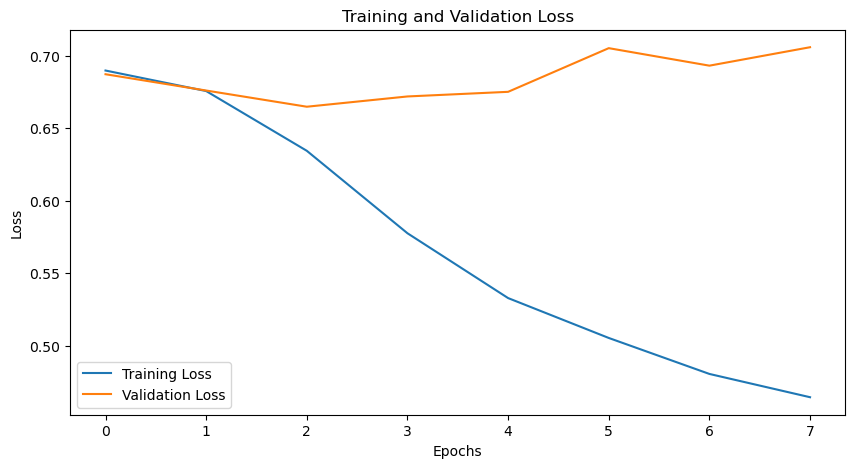

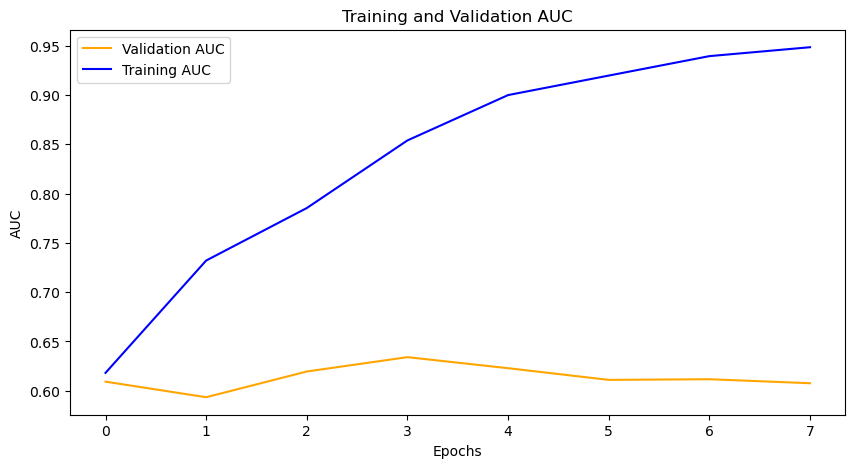

Results DataFrame saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_1\results_df.csv
Patient results saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_1\patient_results.csv
Patient metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_1\patient_metrics.json
Training and validation metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_1\loss_auc_metrics.json
Experiment arguments saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1

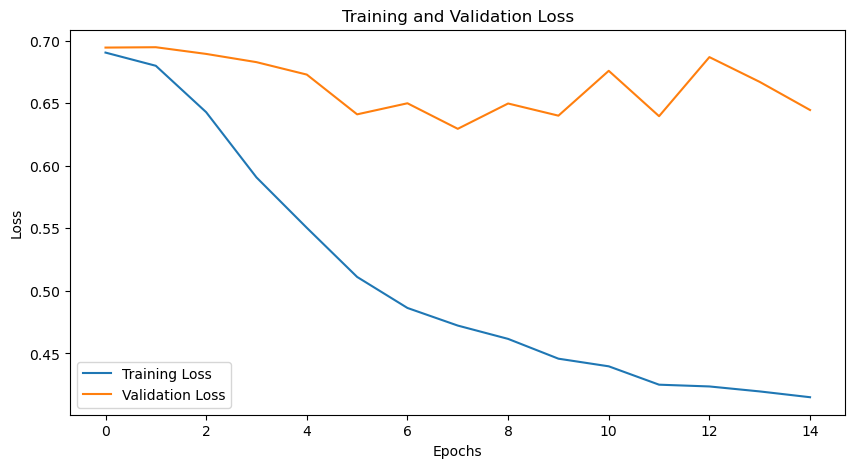

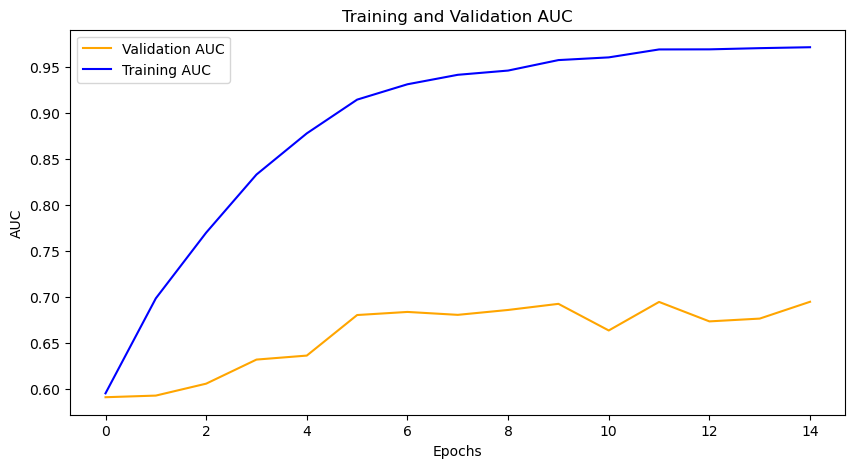

Results DataFrame saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_2\results_df.csv
Patient results saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_2\patient_results.csv
Patient metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_2\patient_metrics.json
Training and validation metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_2\loss_auc_metrics.json
Experiment arguments saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1

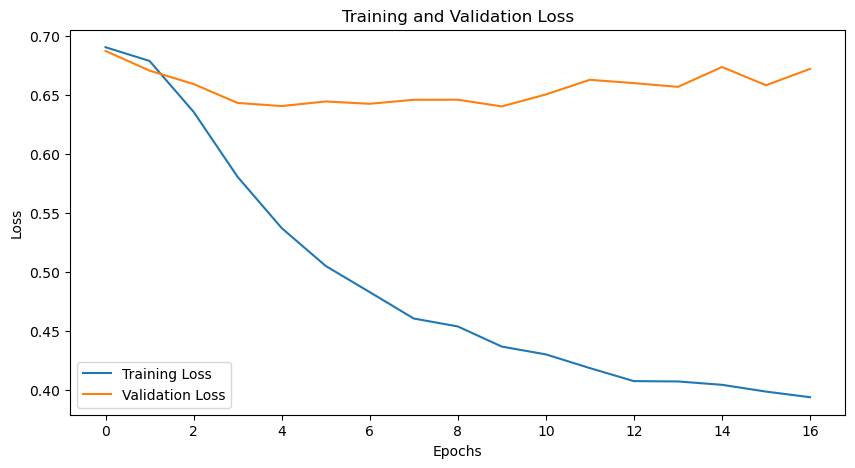

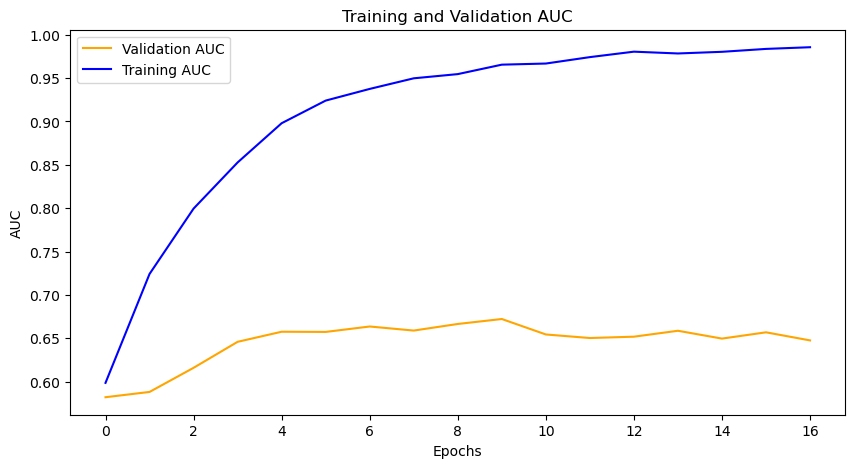

Results DataFrame saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_3\results_df.csv
Patient results saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_3\patient_results.csv
Patient metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_3\patient_metrics.json
Training and validation metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_3\loss_auc_metrics.json
Experiment arguments saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1

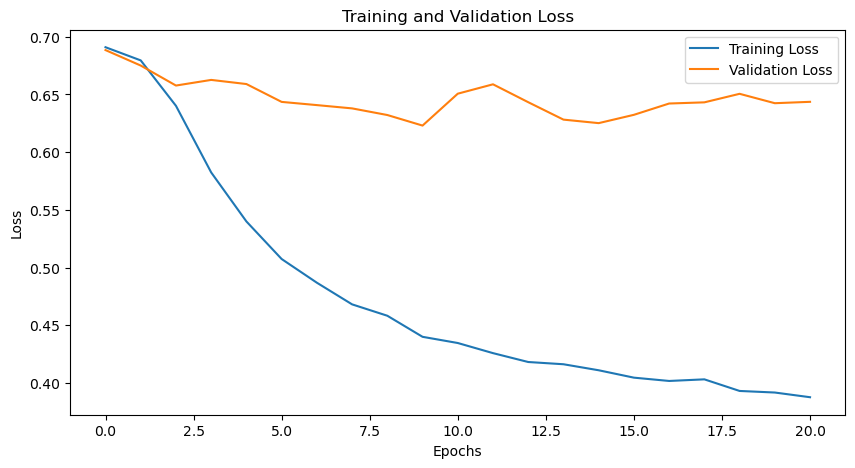

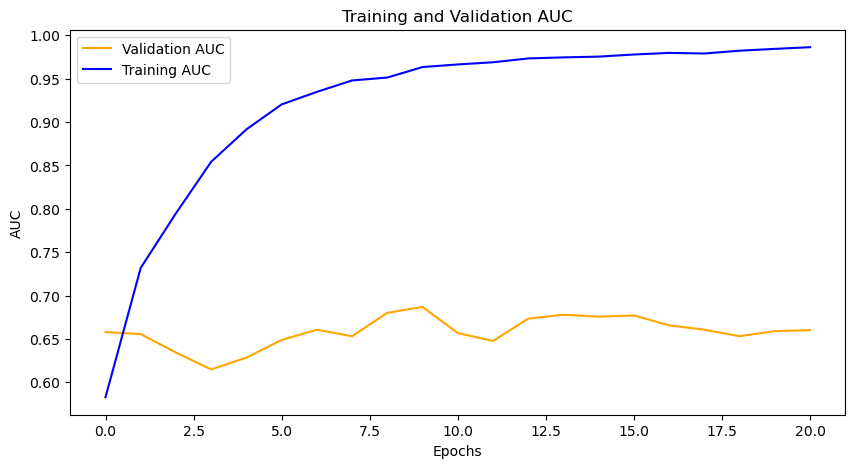

Results DataFrame saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_4\results_df.csv
Patient results saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_4\patient_results.csv
Patient metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_4\patient_metrics.json
Training and validation metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_4\loss_auc_metrics.json
Experiment arguments saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1

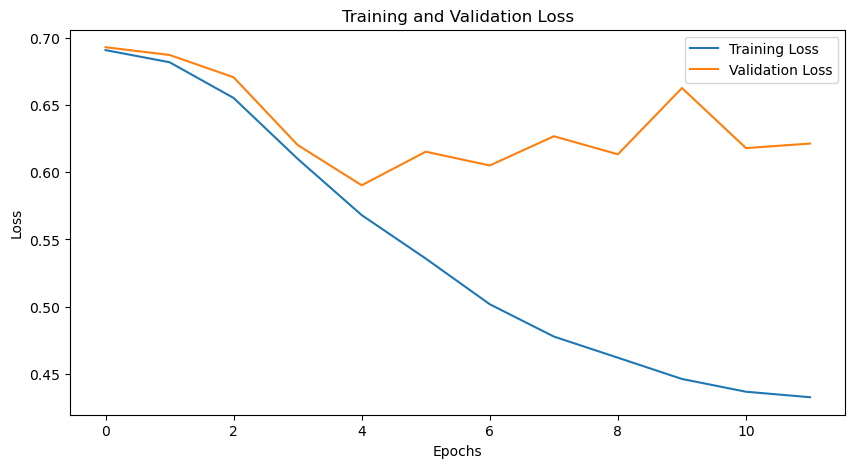

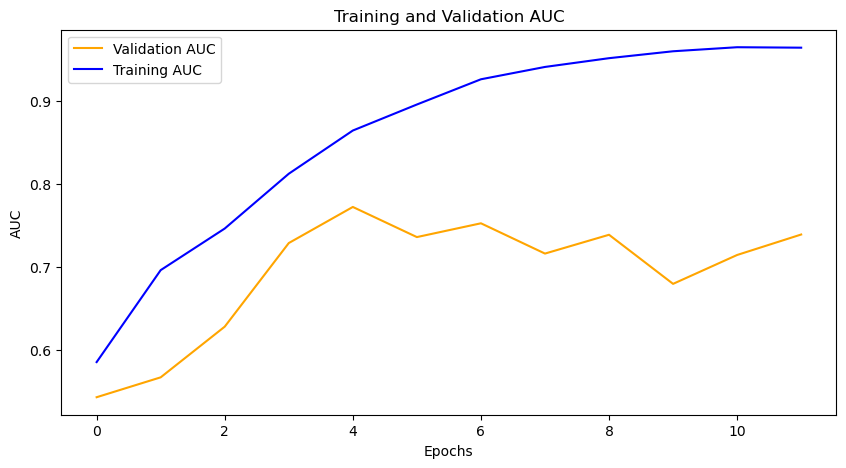

Results DataFrame saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_5\results_df.csv
Patient results saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_5\patient_results.csv
Patient metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_5\patient_metrics.json
Training and validation metrics saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz\fold_5\loss_auc_metrics.json
Experiment arguments saved to D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1

In [34]:
# all_patient_ids, all_labels, all_audio_segments = all_patient_ids_HUMV, all_labels_HUMV, all_audio_segments_HUMV

# Example argument setup
args = {
    'exp_dir': r'D:\Audio_Classification_HUMV_without_GRL\experiments\todos_audios_juntos\EfficientNet_V2_CV_todos_audios_5s_with_1s_overlap_HC_vs_PD_2_testing_AC_raw_22050Hz',
    'n_splits': 5,
    'n_epochs': 30,
    'lr': 1e-5,
    'loss': 'CE',
    'lrscheduler_start': 15,
    'lrscheduler_step': 5,
    'lrscheduler_decay': 0.5,
    'dropout_rate' : 0.2,
    'dropatt_rate': 0.35,
    'CV': True,
    'random_state_split': 42,
    #'audio': "habla_libre_5s_with_1s_overlap",
    'freq_mask': 48,
    'time_mask': 150,
    'std': 1,
    'batch_size': 32,
    'hop_length': 221,
    'n_fft': 552,
    'win_length': 552,
    'n_mels': 128,
    'sr': 22050,
    'augmentation_rate': 0.6,
    'mixup_rate': 0.4,
    'noise' : True,
    'early_stop_patience': 7,  # Number of epochs to wait before stopping
    'monitor_metric': 'val_acc',  # Metric to monitor: 'val_auc', 'val_pm_auc', or 'val_loss'
    'min_delta': 0.001,  # Minimum change to qualify as improvement
    'use_efficientnetv2': True,
    'head_num': 4,
    'b': 0
    }

#audio_model = models.EffNetAttention(label_dim=2, b=2, pretrain=True, head_num=4)
cross_validate_and_save(
    audio_segments=all_audio_segments_HUMV,
    labels_np=all_labels_HUMV,
    patient_ids=all_patient_ids_HUMV,
    args=args,
    #audio_model=audio_model
)